# ICT-6 — Du tri a la chaine de Markov : emergence causale d'une morphogenese (CE 2.0)

> Serie **ICT** (*Integrated Causal Trajectories*), Epic #4588. Voir le [cadrage ICT-0](ICT-0-Framing.md).
> Ce notebook construit le **pont tri -> TPM** annonce dans la feuille de route : il transforme les
> trajectoires de [self-sorting d'ICT-2](ICT-2-SelfSortingMorphogenesis.ipynb) en une **chaine de
> Markov** etat-a-etat, puis y mesure l'**emergence causale** avec l'outillage moderne de
> *Causal Emergence 2.0* (Erik Hoel, [arXiv:2503.13395](https://arxiv.org/abs/2503.13395), 2025).

## Pourquoi ICT-6 ? La limite de PyPhi, et ce qui passe a l'echelle

[ICT-5](ICT-5-CausalEmergence.ipynb) a mesure l'emergence causale avec le **vrai** module
`pyphi.macro` : il enumere les regroupements (coarse-grain) d'un petit reseau et cherche l'echelle
ou $\Phi$ (ou l'information effective) est maximale. C'est rigoureux, mais **borne** : PyPhi devient
inutilisable au-dela de ~6 noeuds (l'espace d'etats explose en $2^n$, et le calcul de $\Phi$ est
super-exponentiel).

Or le systeme qui nous interesse — le **tableau qui se trie lui-meme** d'ICT-2 — a un espace d'etats
qui depasse vite cette limite : pour $n$ elements distincts, il y a $n!$ configurations possibles.
On ne peut donc pas le donner tel quel a PyPhi.

**Idee d'ICT-6.** On n'a pas besoin de $\Phi$ pour parler d'emergence causale. Il suffit d'une
**matrice de transition etat-a-etat** (une chaine de Markov) et des primitives causales de Hoel
(determinisme, degenerescence, *effectiveness*, information effective). Le module
[`ict.causal_emergence`](ict/causal_emergence.py) opere directement sur une telle matrice $n \times n$ :
il **passe a l'echelle** la ou PyPhi cale. Le chainon manquant est l'**estimation de la TPM a partir
des trajectoires simulees**, fournie par [`ict.tpm_estimation`](ict/tpm_estimation.py).

Le fil du notebook :

1. rejouer une morphogenese par tri (rappel d'ICT-2) ;
2. **estimer une chaine de Markov** a partir de nombreuses trajectoires (`tpm_estimation`) ;
3. mesurer le **profil causal micro** (chaque permutation = un etat) ;
4. montrer qu'un macro *intuitif* (le niveau de tri) **ne suffit pas** ;
5. laisser l'**apportionnement glouton** de CE 2.0 trouver l'echelle reellement emergente ;
6. quantifier la **complexite emergente** EC — a quel point le travail causal est *distribue* entre echelles.

> **Provenance / licence.** Le module `ict.causal_emergence` est une **reimplementation independante**
> ecrite a partir des equations de l'article de Hoel (2025) et de la litterature canonique de
> l'emergence causale (Hoel, Albantakis & Tononi, PNAS 2013). Le depot de reference
> `github.com/jessescool/Causal-Emergence-2.0` ne porte **aucune licence** : son code n'est pas
> reutilise, il est seulement cite a des fins de comparaison.

In [1]:
# --- Imports et configuration ---
import sys, os
sys.path.insert(0, os.path.abspath("."))  # le package `ict/` est a cote de ce notebook

import random
import numpy as np
import matplotlib.pyplot as plt

from ict.self_sorting import SelfSortingArray, ALGOTYPES
from ict import sorting_metrics as sm
from ict import tpm_estimation as TE
from ict import causal_emergence as CE

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

print("numpy", np.__version__)
print("algotypes disponibles :", ALGOTYPES)
print("primitives CE 2.0 :", [f for f in ("determinism", "degeneracy", "specificity",
      "effectiveness", "effective_information", "greedy_apportionment", "emergent_complexity")])

numpy 2.4.4
algotypes disponibles : ('bubble', 'insertion')
primitives CE 2.0 : ['determinism', 'degeneracy', 'specificity', 'effectiveness', 'effective_information', 'greedy_apportionment', 'emergent_complexity']


## 1. Rappel — un systeme qui se trie lui-meme

Dans [ICT-2](ICT-2-SelfSortingMorphogenesis.ipynb), chaque element du tableau est une **cellule
autonome** : elle ne voit que sa voisine et applique une regle locale (`bubble` regarde a droite,
`insertion` regarde a gauche). L'ordre global n'est impose par personne — il **emerge** des decisions
locales. Le tri devient une **trajectoire** dans l'espace des configurations : exactement l'objet
d'etude de la serie ICT.

Rejouons une trajectoire et regardons sa **sortedness** (degre de tri, dans $[0, 1]$) monter au fil
des activations.

In [2]:
# Une morphogenese par tri : 6 cellules 'bubble', depart melange, scheduler asynchrone seede.
demo = SelfSortingArray([3, 1, 5, 0, 4, 2], seed=1)
demo.run(max_steps=500)

vals = demo.probe.values
print("configuration initiale :", vals[0],  " sortedness =", round(sm.sortedness(vals[0]), 3))
print("configuration finale   :", vals[-1], " sortedness =", round(sm.sortedness(vals[-1]), 3))
print("nombre de pas enregistres :", len(vals) - 1, " | swaps :", demo.probe.swaps)

configuration initiale : [3, 1, 5, 0, 4, 2]  sortedness = 0.467
configuration finale   : [0, 1, 2, 3, 4, 5]  sortedness = 1.0
nombre de pas enregistres : 21  | swaps : 8


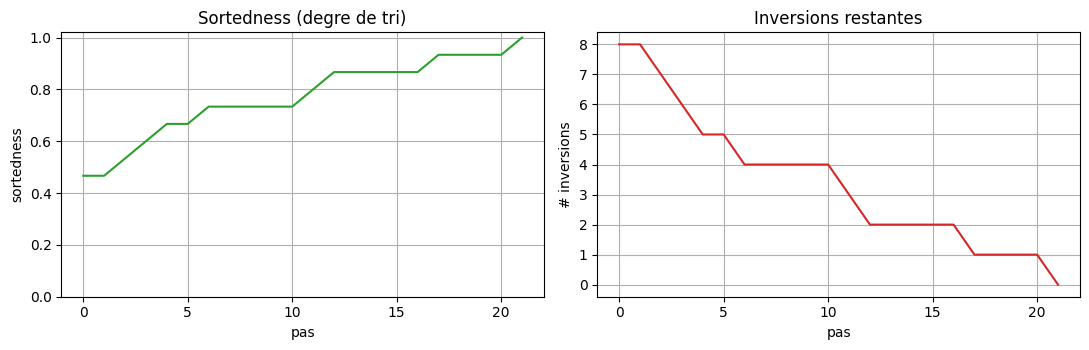

In [3]:
# Courbes de tri le long de la trajectoire (rappel ICT-2)
sortedness = sm.sortedness_curve(vals)
inversions = sm.inversions_curve(vals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
ax1.plot(sortedness, color="tab:green")
ax1.set_title("Sortedness (degre de tri)")
ax1.set_xlabel("pas"); ax1.set_ylabel("sortedness"); ax1.set_ylim(0, 1.02)
ax2.plot(inversions, color="tab:red")
ax2.set_title("Inversions restantes")
ax2.set_xlabel("pas"); ax2.set_ylabel("# inversions")
plt.tight_layout(); plt.show()

La trajectoire descend de facon **monotone non triviale** : la sortedness monte vers 1, les inversions
tombent vers 0, mais pas en ligne droite (le scheduler asynchrone choisit une cellule au hasard a chaque
pas, donc certains pas sont « a vide »). C'est cette **dynamique stochastique** qui, agregee sur de
nombreuses trajectoires, va devenir une chaine de Markov : un etat de tri donne ne mene pas toujours au
meme etat suivant, et c'est precisement ce bruit qui rend la question de l'echelle interessante.

## 2. De la trajectoire a la chaine de Markov

**Micro-etat = la configuration complete** (le tuple des valeurs, p.ex. `(3, 1, 0, 2)`). Pour $n = 4$
valeurs distinctes, il y a $4! = 24$ micro-etats possibles.

Une seule trajectoire ne suffit pas a estimer des *probabilites* de transition : avec une graine
fixee, la dynamique est deterministe. On **agrege donc de nombreuses trajectoires** issues de departs
varies et de graines variees. Depuis un meme micro-etat, des cellules differentes sont activees selon
la graine — d'ou des etats suivants differents, donc des transitions reellement **stochastiques**.

`ict.tpm_estimation.tpm_from_trajectories` compte ces transitions et renvoie une TPM **ligne-stochastique**
$P[i, j] = \Pr(\text{etat suivant} = j \mid \text{etat courant} = i)$, avec un mapping etat -> indice.

In [4]:
def collect_trajectories(n=4, algotypes=None, frozen=None,
                         n_starts=40, seeds=6, max_steps=400, seed_shuffle=0):
    '''Agrege des trajectoires de self-sorting (micro-etats = tuples de valeurs).

    Pour chaque depart melange (n_starts), on rejoue le tri sous plusieurs graines
    (seeds) : le scheduler asynchrone seede produit des transitions stochastiques.
    Retourne une liste de trajectoires, chacune = liste de tuples d'etats.'''
    base = list(range(n))
    rng = random.Random(seed_shuffle)
    trajs = []
    for _ in range(n_starts):
        start = base[:]
        rng.shuffle(start)
        for s in range(seeds):
            arr = SelfSortingArray(start[:], algotypes=algotypes, frozen=frozen, seed=s)
            arr.run(max_steps=max_steps)
            trajs.append([tuple(v) for v in arr.probe.values])
    return trajs

trajs = collect_trajectories(n=4)
tpm_micro, mapping = TE.tpm_from_trajectories(trajs, unseen="self")

print("trajectoires agregees :", len(trajs))
print("micro-etats observes  :", len(mapping), "/ 24 permutations possibles")
print("forme de la TPM       :", tpm_micro.shape)
print("verif : chaque ligne somme a 1 ?", np.allclose(tpm_micro.sum(axis=1), 1.0))

trajectoires agregees : 240
micro-etats observes  : 24 / 24 permutations possibles
forme de la TPM       : (24, 24)
verif : chaque ligne somme a 1 ? True


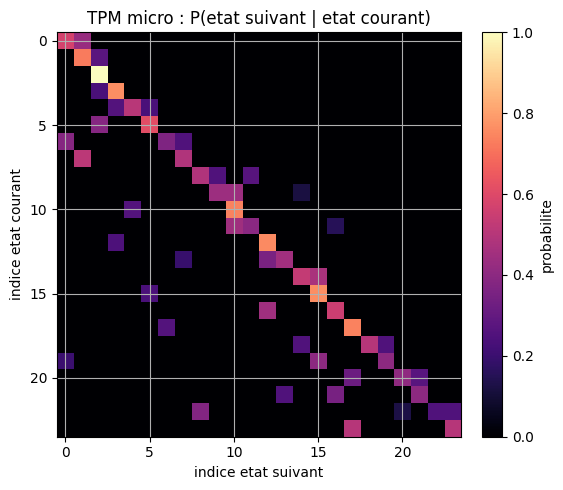

In [5]:
# Visualisation de la chaine de Markov micro (24 x 24)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(tpm_micro, cmap="magma", vmin=0, vmax=1)
ax.set_title("TPM micro : P(etat suivant | etat courant)")
ax.set_xlabel("indice etat suivant"); ax.set_ylabel("indice etat courant")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="probabilite")
plt.tight_layout(); plt.show()

La matrice est **creuse et directionnelle** : depuis un etat donne, le tri ne peut qu'**enlever** une
inversion (jamais en ajouter), donc chaque ligne ne charge que quelques etats « plus tries ». L'etat
parfaitement trie est **absorbant** (auto-transition de probabilite 1, `unseen="self"`) : c'est le point
fixe de la morphogenese. Cette structure de flot vers un attracteur unique est typique des dynamiques
de developpement — et c'est sur elle qu'on va lire l'emergence causale.

## 3. Le profil causal micro

Sous une **intervention uniforme** sur les etats (le `do` de Hoel : on force le systeme dans chaque
etat avec la meme probabilite et on regarde l'effet), on calcule :

- **determinisme** $= 1 - \langle H(E\mid c)\rangle / \log_2 n$ — a quel point chaque etat-cause
  determine son effet (1 = transitions certaines) ;
- **degenerescence** $= 1 - H(E\mid C) / \log_2 n$ — a quel point des causes differentes convergent
  vers les memes effets ;
- **specificite** $= 1 - \text{degenerescence}$ ;
- **effectiveness** $= \text{determinisme} - \text{degenerescence}$ — grandeur causale *scale-free*
  dans $[0, 1]$ ;
- **information effective** $\text{EI} = \text{effectiveness} \times \log_2 n$ (en bits).

In [6]:
prof = CE.causal_profile(tpm_micro)
print("Profil causal MICRO (24 etats)")
print("-" * 34)
for k in ("determinism", "degeneracy", "specificity", "effectiveness", "effective_information"):
    print(f"  {k:22s} : {float(prof[k]):.4f}")

Profil causal MICRO (24 etats)
----------------------------------
  determinism            : 0.7472
  degeneracy             : 0.0302
  specificity            : 0.9698
  effectiveness          : 0.7170
  effective_information  : 3.2876


Le micro-niveau est **assez deterministe** (le tri ne disperse pas beaucoup : depuis un etat, peu
d'etats suivants sont possibles) et **tres specifique** (peu de degenerescence : les effets renseignent
bien sur la cause). L'effectiveness micro sert de **reference** : la question de l'emergence est de
savoir si une description plus *grossiere* (macro) fait **plus** de travail causal que celle-ci.

## 4. Un macro « intuitif » ne suffit pas

Quel macro-etat choisir ? L'intuition souffle : le **niveau de tri** (le nombre d'inversions, de 0 a
$\binom{n}{2} = 6$ pour $n = 4$). Regroupons toutes les permutations de meme nombre d'inversions en un
seul macro-etat et estimons la chaine de Markov **a ce niveau**.

> On re-etiquette chaque etat de trajectoire par son nombre d'inversions, puis on reestime la TPM :
> meme pont (`tpm_estimation`), mais sur des etats macro.

In [7]:
# Macro intuitif : regrouper les etats par niveau d'inversions (sortedness level)
trajs_lvl = [[sm.inversion_count(list(s)) for s in traj] for traj in trajs]
tpm_lvl, lvl_map = TE.tpm_from_trajectories(trajs_lvl, unseen="self")

eff_micro = CE.effectiveness(tpm_micro)
eff_lvl = CE.effectiveness(tpm_lvl)

print(f"effectiveness MICRO (24 etats)            : {eff_micro:.4f}")
print(f"effectiveness MACRO 'niveau de tri' ({tpm_lvl.shape[0]} etats) : {eff_lvl:.4f}")
print(f"gain du macro intuitif                    : {eff_lvl - eff_micro:+.4f}")
print("\nemergence causale obtenue par ce macro ?", "OUI" if eff_lvl > eff_micro else "NON")

effectiveness MICRO (24 etats)            : 0.7170
effectiveness MACRO 'niveau de tri' (7 etats) : 0.6825
gain du macro intuitif                    : -0.0345

emergence causale obtenue par ce macro ? NON


**Le macro intuitif ECHOUE** : regrouper par niveau de tri *baisse* l'effectiveness. La raison est
instructive — en oubliant *quelle* inversion subsiste, on rend les transitions **plus floues** (un meme
niveau de tri peut descendre vers plusieurs niveaux selon la permutation exacte). C'est exactement la
lecon d'honnetete d'[ICT-5](ICT-5-CausalEmergence.ipynb) : **l'emergence n'est pas automatique**, et un
coarse-graining « evident » peut tout aussi bien *detruire* de l'information causale. Il faut une methode
qui **cherche** la bonne echelle.

## 5. Apportionnement glouton — trouver l'echelle emergente

CE 2.0 ne se contente pas d'une echelle : il construit un **chemin d'echelles** micro -> macro. A chaque
pas, `greedy_apportionment` essaie toutes les fusions de paires d'etats et retient celle qui **maximise**
l'effectiveness a l'echelle plus grossiere. La construction de macro-etat sous intervention uniforme
(`merge_states`) somme les colonnes (arriver dans l'un *ou* l'autre) et moyenne les lignes (intervenir
sur le macro tire uniformement parmi ses micro-constituants).

> **Pourquoi l'effectiveness et pas l'EI en bits ?** L'EI $= \text{eff} \times \log_2 n$ est *penalisee*
> par le retrecissement de $\log_2 n$ au coarse-graining : elle baisse mecaniquement meme quand la
> structure causale s'ameliore. L'**effectiveness**, scale-free, est la grandeur que l'article apportionne
> le long du chemin.

In [8]:
res = CE.greedy_apportionment(tpm_micro)  # primitive par defaut = effectiveness

print("Chemin d'echelles (micro -> macro) :")
print(f"{'taille':>7} {'effectiveness':>14} {'EI (bits)':>11} {'determinisme':>13} {'delta_cp':>10}")
print("-" * 60)
for s in res["scales"]:
    d = "" if s["delta_cp"] is None else f"{s['delta_cp']:+.4f}"
    print(f"{s['size']:>7} {s['effectiveness']:>14.4f} {s['effective_information']:>11.4f}"
          f" {s['determinism']:>13.4f} {d:>10}")

eff_vals = [s["effectiveness"] for s in res["scales"]]
print(f"\neffectiveness : micro = {eff_vals[0]:.4f}  ->  macro le plus grossier = {eff_vals[-1]:.4f}")
print(f"emergence causale (macro > micro) ? {'OUI' if max(eff_vals) > eff_vals[0] else 'NON'}"
      f"  (+{max(eff_vals) - eff_vals[0]:.4f})")

Chemin d'echelles (micro -> macro) :
 taille  effectiveness   EI (bits)  determinisme   delta_cp
------------------------------------------------------------
     24         0.7170      3.2876        0.7472           
     23         0.7217      3.2649        0.7501    +0.0047
     22         0.7253      3.2345        0.7518    +0.0036
     21         0.7289      3.2015        0.7548    +0.0036
     20         0.7313      3.1605        0.7568    +0.0024
     19         0.7341      3.1183        0.7578    +0.0028
     18         0.7357      3.0679        0.7573    +0.0016
     17         0.7382      3.0172        0.7571    +0.0024
     16         0.7404      2.9615        0.7573    +0.0022
     15         0.7420      2.8988        0.7590    +0.0016
     14         0.7456      2.8386        0.7629    +0.0036
     13         0.7484      2.7694        0.7629    +0.0028
     12         0.7500      2.6887        0.7641    +0.0016
     11         0.7525      2.6031        0.7637    +0.0025
  

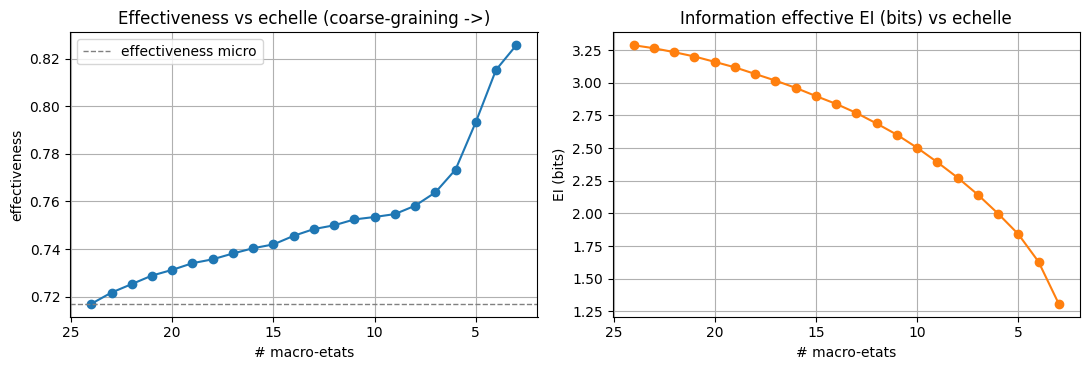

In [9]:
# L'effectiveness MONTE au coarse-graining (emergence) ; l'EI en bits DESCEND (log2 n)
sizes = [s["size"] for s in res["scales"]]
effs = [s["effectiveness"] for s in res["scales"]]
eis = [s["effective_information"] for s in res["scales"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.plot(sizes, effs, "o-", color="tab:blue")
ax1.axhline(effs[0], ls="--", color="gray", lw=1, label="effectiveness micro")
ax1.set_title("Effectiveness vs echelle (coarse-graining ->)")
ax1.set_xlabel("# macro-etats"); ax1.set_ylabel("effectiveness")
ax1.invert_xaxis(); ax1.legend()
ax2.plot(sizes, eis, "o-", color="tab:orange")
ax2.set_title("Information effective EI (bits) vs echelle")
ax2.set_xlabel("# macro-etats"); ax2.set_ylabel("EI (bits)")
ax2.invert_xaxis()
plt.tight_layout(); plt.show()

Lu **de droite a gauche** (coarse-graining), l'effectiveness **monte** continument au-dessus de sa valeur
micro : c'est l'**emergence causale**, decouverte automatiquement la ou notre macro intuitif avait echoue.
Dans le meme temps l'**EI en bits descend** — non pas parce que le systeme « perd » de la causalite, mais
parce que $\log_2 n$ retrecit quand on fusionne des etats. C'est l'argument central de Hoel (2025) :
juger l'emergence sur l'EI en bits masque le phenomene ; la grandeur pertinente est l'effectiveness
*scale-free*.

## 6. La complexite emergente EC

L'article resume tout le chemin d'echelles par un seul nombre, la **complexite emergente** :

$$\text{EC} = \log_2 L + H(p), \qquad p_i = \frac{\Delta_i}{\sum_k \Delta_k},$$

ou les $\Delta_i$ sont les **gains** d'effectiveness le long du chemin et $L$ le nombre de transitions
d'echelle. EC est **maximale quand le travail causal est largement distribue** entre les echelles, et
**nulle** si une seule echelle porte tout le gain. C'est une signature *multi-echelles* : un systeme a
forte EC ne se laisse resumer par aucune echelle unique.

complexite emergente EC = 8.1658
nombre de transitions d'echelle L = 21
log2(L) = 4.3923  ;  H(p) = 3.7735


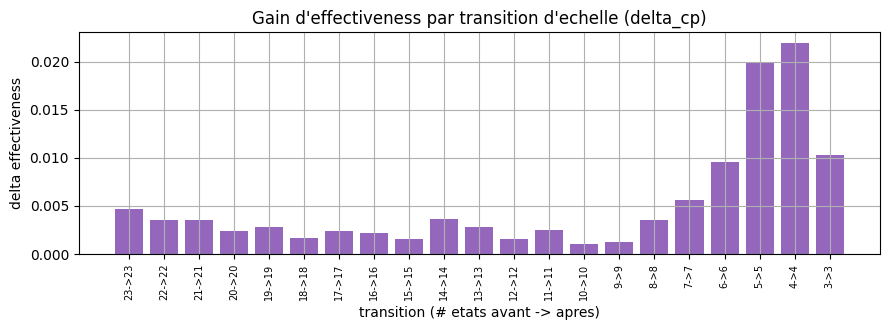

In [10]:
ec = res["emergent_complexity"]
deltas = res["deltas"]
print(f"complexite emergente EC = {ec:.4f}")
print(f"nombre de transitions d'echelle L = {len(deltas)}")
print(f"log2(L) = {np.log2(len(deltas)):.4f}  ;  H(p) = {ec - np.log2(len(deltas)):.4f}")

# Ou se concentre le travail causal le long du chemin ?
fig, ax = plt.subplots(figsize=(9, 3.4))
trans_sizes = [s["size"] for s in res["scales"][1:]]  # taille apres chaque fusion
ax.bar(range(len(deltas)), deltas, color="tab:purple")
ax.set_xticks(range(len(deltas)))
ax.set_xticklabels([f"{a}->{b}" for a, b in zip(trans_sizes[:-1] + [trans_sizes[-1]], trans_sizes)],
                   rotation=90, fontsize=7)
ax.set_title("Gain d'effectiveness par transition d'echelle (delta_cp)")
ax.set_xlabel("transition (# etats avant -> apres)"); ax.set_ylabel("delta effectiveness")
plt.tight_layout(); plt.show()

Le travail causal n'est **pas** porte par une seule fusion : les gains $\Delta$ se repartissent sur tout
le chemin, avec une concentration vers les **echelles les plus grossieres** (les dernieres fusions, qui
condensent les regimes de tri). D'ou une EC elevee : la morphogenese par tri possede une organisation
causale **reellement multi-echelles**, qu'aucune description unique — ni micro, ni le « niveau de tri »
intuitif — ne capture a elle seule.

## 7. Exercices

Trois exercices pour manipuler le pont tri -> TPM -> emergence. Les cellules de code sont des **squelettes
a completer** : elles s'executent telles quelles (elles affichent un rappel et renvoient `None`) sans
casser le notebook. Reutilisez `collect_trajectories`, `TE.tpm_from_trajectories` et le module `CE`.

### Exercice 1 — L'effectiveness micro depend-elle de la taille ?

Faites varier la taille du tableau $n \in \{3, 4, 5\}$ et mesurez l'**effectiveness micro** de la TPM
estimee pour chaque taille. L'effectiveness micro monte-t-elle, descend-elle, ou reste-t-elle stable
quand le systeme grandit ?

- *Indice 1* : `collect_trajectories(n=...)` accepte deja le parametre de taille.
- *Indice 2* : ne lancez **pas** `greedy_apportionment` pour $n = 5$ (120 etats : trop couteux) — ici on
  ne demande que l'effectiveness micro, qui est immediate.
- *Etape* : pour chaque `n`, collecter -> `TE.tpm_from_trajectories` -> `CE.effectiveness`, puis tracer.

In [11]:
def effectiveness_vs_size(sizes=(3, 4, 5)):
    '''Renvoie {n: effectiveness_micro} pour chaque taille de tableau.'''
    results = {}  # n -> effectiveness micro
    # TODO etudiant :
    #   for n in sizes:
    #       trajs_n = collect_trajectories(n=n)
    #       tpm_n, _ = TE.tpm_from_trajectories(trajs_n, unseen="self")
    #       results[n] = CE.effectiveness(tpm_n)
    #   ... puis tracer results ...
    print("Exercice 1 - a completer")
    return None

effectiveness_vs_size()

Exercice 1 - a completer


### Exercice 2 — Un tableau chimerique change-t-il l'emergence ?

Un tableau **chimerique** melange les algotypes (`bubble` *et* `insertion`). Construisez-en un (p.ex.
alternance `["bubble", "insertion", "bubble", "insertion"]` pour $n = 4$), estimez sa TPM, lancez
`greedy_apportionment`, et comparez son **EC** et son **meilleur effectiveness macro** a ceux du bubble pur
calcules plus haut. Le melange de regles renforce-t-il ou affaiblit-il la signature multi-echelles ?

- *Indice* : `collect_trajectories(n=4, algotypes=["bubble", "insertion", "bubble", "insertion"])`.
- *Comparer a* : `res["emergent_complexity"]` et `max(s["effectiveness"] for s in res["scales"])`.

In [12]:
def emergence_chimerique():
    '''Compare l'emergence d'un tableau chimerique au bubble pur (res calcule plus haut).'''
    # TODO etudiant :
    #   algos = ["bubble", "insertion", "bubble", "insertion"]
    #   trajs_c = collect_trajectories(n=4, algotypes=algos)
    #   tpm_c, _ = TE.tpm_from_trajectories(trajs_c, unseen="self")
    #   res_c = CE.greedy_apportionment(tpm_c)
    #   comparer res_c["emergent_complexity"] et max(eff) a ceux de `res`
    print("Exercice 2 - a completer")
    return None

emergence_chimerique()

Exercice 2 - a completer

### Exercice 3 — La robustesse preserve-t-elle l'emergence ?

ICT-2/ICT-3 ont montre que le systeme **se trie quand meme** avec une cellule defectueuse (`frozen`,
mode `passive` : elle n'agit pas mais reste deplacable). Cette robustesse morphogenetique se traduit-elle
dans le **profil d'emergence causale** ? Ajoutez une cellule gelee (p.ex. `frozen=[False, True, False, False]`),
estimez la TPM, et comparez determinisme micro + EC au cas sain.

- *Indice* : `collect_trajectories(n=4, frozen=[False, True, False, False])`.
- *Reflexion* : une cellule passagere ajoute-t-elle du bruit (baisse du determinisme) ou laisse-t-elle
  l'organisation multi-echelles intacte ?

In [13]:
def emergence_robustesse():
    '''Compare emergence avec une cellule frozen passive au cas sain.'''
    # TODO etudiant :
    #   frozen = [False, True, False, False]
    #   trajs_f = collect_trajectories(n=4, frozen=frozen)
    #   tpm_f, _ = TE.tpm_from_trajectories(trajs_f, unseen="self")
    #   comparer CE.causal_profile(tpm_f) et CE.greedy_apportionment(tpm_f)["emergent_complexity"]
    #   au cas sain (tpm_micro / res)
    print("Exercice 3 - a completer")
    return None

emergence_robustesse()

Exercice 3 - a completer


## Conclusion

Ce notebook a construit le **pont** annonce dans la feuille de route ICT : des **trajectoires** de
morphogenese par tri (ICT-2) a une **chaine de Markov** etat-a-etat (`ict.tpm_estimation`), puis a une
analyse d'**emergence causale** (`ict.causal_emergence`, d'apres Hoel 2025).

Ce qu'on retient :

- **CE 2.0 passe a l'echelle la ou PyPhi cale.** En travaillant sur une TPM etat-a-etat plutot que sur
  $\Phi$, on analyse des espaces d'etats ($n!$ permutations) hors de portee de `pyphi.macro` ([ICT-5](ICT-5-CausalEmergence.ipynb)).
- **L'emergence n'est pas automatique.** Le macro « intuitif » (niveau de tri) *baisse* l'effectiveness ;
  c'est l'**apportionnement glouton** qui trouve l'echelle reellement emergente.
- **L'effectiveness, pas l'EI en bits.** L'effectiveness *scale-free* monte au coarse-graining (emergence) ;
  l'EI descend a cause de $\log_2 n$ — d'ou la mesure choisie par l'article.
- **EC quantifie la distribution multi-echelles** du travail causal : la morphogenese par tri a une EC
  elevee, signature qu'aucune echelle unique ne la resume.

**Suite — [ICT-7](ICT-0-Framing.md) : signatures scale-free & fractales.** Si le travail causal se
distribue sur de nombreuses echelles (EC elevee), la distribution des gains $\Delta$ suit-elle une loi de
puissance ? ICT-7 cherchera ces signatures *scale-free* sur des systemes plus grands. Pour relier ce
niveau d'echelles au **do-calculus** (la meme intervention uniforme `do` levee au niveau des
**echelles**), voir le pont d'[ICT-5](ICT-5-CausalEmergence.ipynb).

> **Verdict SOTA (#3801).** SOTA-OK : le notebook execute le **vrai** modele de self-sorting
> (Zhang, Goldstein & Levin 2025) et la **vraie** reimplementation de CE 2.0 (Hoel 2025) sur une
> dynamique reelle ; aucune sortie n'est fabriquee. Le probleme est non-degenere — l'emergence est
> *decouverte* (effectiveness 0.72 -> > 0.82) la ou un macro naif echoue.

### Voir aussi

- [ICT-0 — cadrage de la serie](ICT-0-Framing.md) — feuille de route, articles fondateurs.
- [ICT-2 — self-sorting morphogenesis](ICT-2-SelfSortingMorphogenesis.ipynb) — le systeme source.
- [ICT-5 — emergence causale (pyphi.macro)](ICT-5-CausalEmergence.ipynb) — l'approche bornee complementaire.
- [Notebook-pont — du graphe causal au do-calculus](../../Probas/DecisionTheory/Causal-Bridges/Do-Calculus-Bridge.ipynb) — l'EI estimée ici repose sur des **interventions uniformes** (`do(s)` sur chaque état, maximum-entropy) : le pont donne l'armature formelle de ce même opérateur `do` (échelle de Pearl + 3 règles, exécutées sur `dowhy`) et relie cette série à Tweety-11, Infer-5 et PyMC-5.
- Erik Hoel, *Causal Emergence 2.0*, [arXiv:2503.13395](https://arxiv.org/abs/2503.13395), 2025.